# Panel Diagnostics
## Guadalupe River SCM Recovery — Phase 5, Step 1

**Purpose:** Validate the SCM panel before estimation. Understand data coverage, Comal County's pre-treatment trajectory, and how it compares to the donor pool.

**Treated unit:** Comal County, TX (FIPS 48091)  
**Treatment event:** October 1998 Guadalupe River Flood (DR-1257-TX)  
**Study period:** 1978–2024 (pre-treatment: 1978–1998, post-treatment: 1999–2024)  
**Cleanest pre-treatment window:** 1990–1998 (all major sources available)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from src.utils.file_io import load_parquet

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
COMAL_COLOR  = '#d62728'   # red for treated unit
DONOR_COLOR  = '#aec7e8'   # light blue for donor pool
MEDIAN_COLOR = '#1f77b4'   # dark blue for donor median
TREATMENT_YEAR = 1999
TREATED_FIPS   = '48091'
print('Setup complete.')

Setup complete.


## 1  Load Data

In [2]:
panel = load_parquet('../data/processed/panels/scm_panel.parquet')

# Basic info
print(f'Panel shape: {panel.shape}')
print(f'Counties: {panel["fips"].nunique()}')
print(f'Years: {panel["year"].min()} – {panel["year"].max()}')
print(f'Donor-eligible: {panel[panel["donor_eligible"]==True]["fips"].nunique()} counties')

# Subsets
comal  = panel[panel['fips'] == TREATED_FIPS].sort_values('year').copy()
donors = panel[(panel['donor_eligible'] == True)].copy()
print(f'\nComal rows: {len(comal)}')

Panel shape: (11938, 63)
Counties: 254
Years: 1978 – 2024
Donor-eligible: 171 counties

Comal rows: 47


In [3]:
# Load availability matrix
avail = pd.read_csv('../data/processed/panels/availability_matrix.csv', index_col=0)
avail.index.name = 'source'
print('Availability matrix shape:', avail.shape)
avail.head(6)

Availability matrix shape: (423, 4)


,year,counties_with_data,total_counties,coverage
source,,,,
BEA,1978,254,254,1.0
BEA,1979,254,254,1.0
BEA,1980,254,254,1.0
BEA,1981,254,254,1.0
BEA,1982,254,254,1.0
BEA,1983,254,254,1.0


## 2  Coverage Heatmap

For each data source and year, what share of counties have data?  
A vertical dashed line marks the 1998 treatment event.

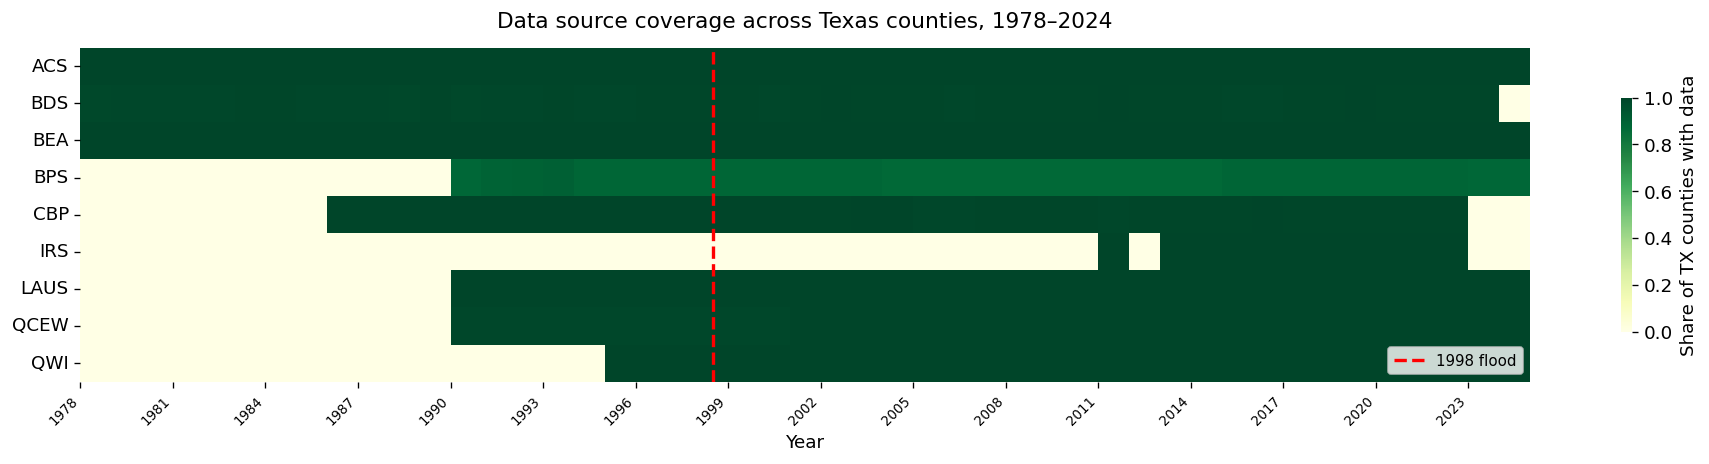

Saved: data/processed/panels/coverage_heatmap.png


In [4]:
# Pivot: sources as rows, years as columns
avail_pct = avail.reset_index().pivot_table(
    index='source', columns='year', values='coverage', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    avail_pct,
    cmap='YlGn',
    vmin=0, vmax=1,
    linewidths=0,
    ax=ax,
    cbar_kws={'label': 'Share of TX counties with data', 'shrink': 0.7},
)

# Mark 1998
years = avail_pct.columns.tolist()
if 1998 in years:
    x_pos = years.index(1998) + 0.5
    ax.axvline(x_pos, color='red', linewidth=2, linestyle='--', label='1998 flood')
    ax.legend(loc='lower right', fontsize=9)

ax.set_title('Data source coverage across Texas counties, 1978–2024', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('')
# Thin x-tick labels
n = len(years)
step = max(1, n // 12)
ax.set_xticks(range(0, n, step))
ax.set_xticklabels([years[i] for i in range(0, n, step)], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/panels/coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/panels/coverage_heatmap.png')

## 3  Comal County: Missing Data Audit

How many missing values does Comal County have per variable, and in which years?

In [5]:
# Per-variable missingness for Comal
outcome_cols = [
    'per_capita_income_real', 'personal_income_real', 'net_earnings_real',
    'transfer_receipts_real',
    'laus_unemployment_rate', 'laus_employment', 'laus_labor_force',
    'emp_pop_ratio',
    'qcew_employment', 'qcew_avg_annual_pay_real', 'qcew_establishments',
    'cbp_employment', 'cbp_annual_payroll_real', 'cbp_establishments',
    'bps_units', 'bps_value_real',
    'qwi_emp', 'qwi_earnings_real',
    'net_job_creation_rate',
    'median_household_income_real', 'poverty_rate', 'college_share',
]

comal_miss = []
for col in outcome_cols:
    if col not in comal.columns:
        continue
    n_miss = comal[col].isna().sum()
    first_valid = comal.loc[comal[col].notna(), 'year'].min() if n_miss < len(comal) else None
    last_valid  = comal.loc[comal[col].notna(), 'year'].max() if n_miss < len(comal) else None
    comal_miss.append({
        'variable': col,
        'n_missing': n_miss,
        'pct_missing': round(100 * n_miss / len(comal), 1),
        'first_year': first_valid,
        'last_year': last_valid,
    })

miss_df = pd.DataFrame(comal_miss).sort_values('n_missing', ascending=False)
print(f'Total Comal rows: {len(comal)}')
miss_df

Total Comal rows: 47


,variable,n_missing,pct_missing,first_year,last_year
16,qwi_emp,17,36.2,1995,2024
17,qwi_earnings_real,17,36.2,1995,2024
7,emp_pop_ratio,12,25.5,1990,2024
15,bps_value_real,12,25.5,1990,2024
14,bps_units,12,25.5,1990,2024
10,qcew_establishments,12,25.5,1990,2024
9,qcew_avg_annual_pay_real,12,25.5,1990,2024
8,qcew_employment,12,25.5,1990,2024
6,laus_labor_force,12,25.5,1990,2024
5,laus_employment,12,25.5,1990,2024


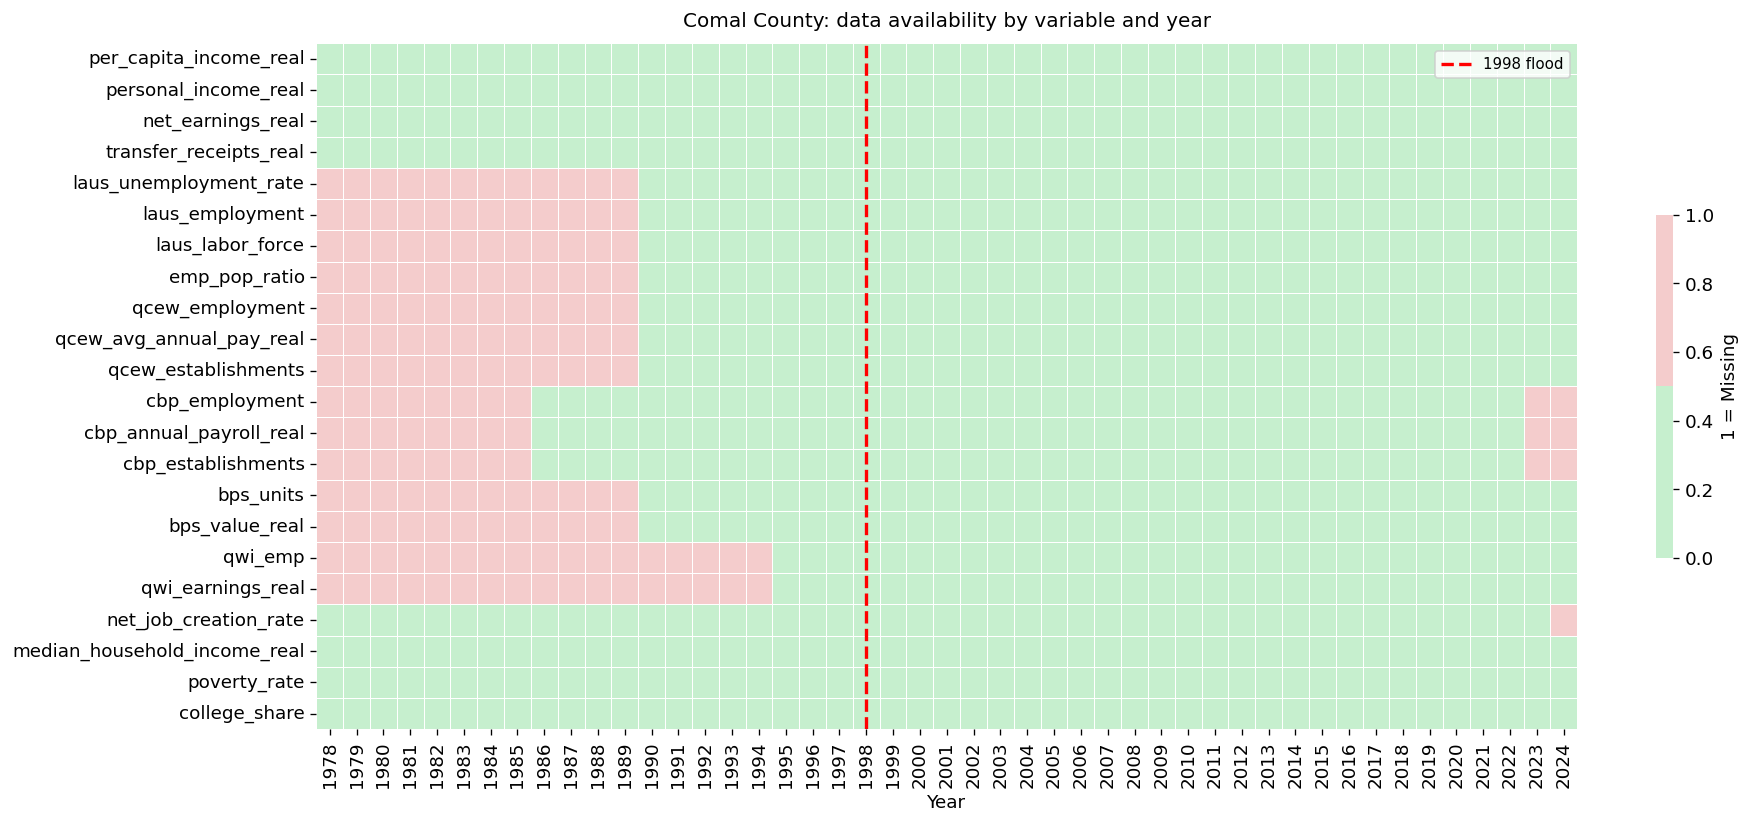

In [6]:
# Year-by-year missingness heatmap for key variables (Comal only)
key_vars = [c for c in outcome_cols if c in comal.columns]
comal_miss_mat = comal.set_index('year')[key_vars].isnull().astype(int).T

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    comal_miss_mat,
    cmap=['#c6efce', '#f4cccc'],  # green=present, red=missing
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': '1 = Missing', 'shrink': 0.5},
)
ax.axvline(
    comal_miss_mat.columns.tolist().index(1998) + 0.5,
    color='red', linewidth=2, linestyle='--', label='1998 flood'
)
ax.set_title('Comal County: data availability by variable and year', fontsize=12, pad=10)
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 4  Pre-Treatment Trends: Comal vs. Donor Pool

Key outcomes from 1978 (or first available year) through 2024.  
Gray lines = individual donor counties; blue line = donor median; red line = Comal County.  
Dashed vertical line = 1999 (first post-treatment year).

In [7]:
def plot_trends(outcome, ylabel, title, log_scale=False, ax=None):
    """Plot Comal vs. donor pool trend for a single outcome variable."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    
    # Donor pool (individual lines)
    for fips, grp in donors.groupby('fips'):
        ax.plot(grp['year'], grp[outcome], color=DONOR_COLOR, alpha=0.3, linewidth=0.6)
    
    # Donor median
    donor_med = donors.groupby('year')[outcome].median()
    ax.plot(donor_med.index, donor_med.values, color=MEDIAN_COLOR,
            linewidth=2, label='Donor pool median', zorder=3)
    
    # Comal
    ax.plot(comal['year'], comal[outcome], color=COMAL_COLOR,
            linewidth=2.5, label='Comal County', zorder=4)
    
    # Flood marker
    ax.axvline(TREATMENT_YEAR, color='black', linewidth=1.2,
               linestyle='--', alpha=0.7, label='1999 (post-treatment)')
    
    if log_scale:
        ax.set_yscale('log')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc='upper left')
    return ax

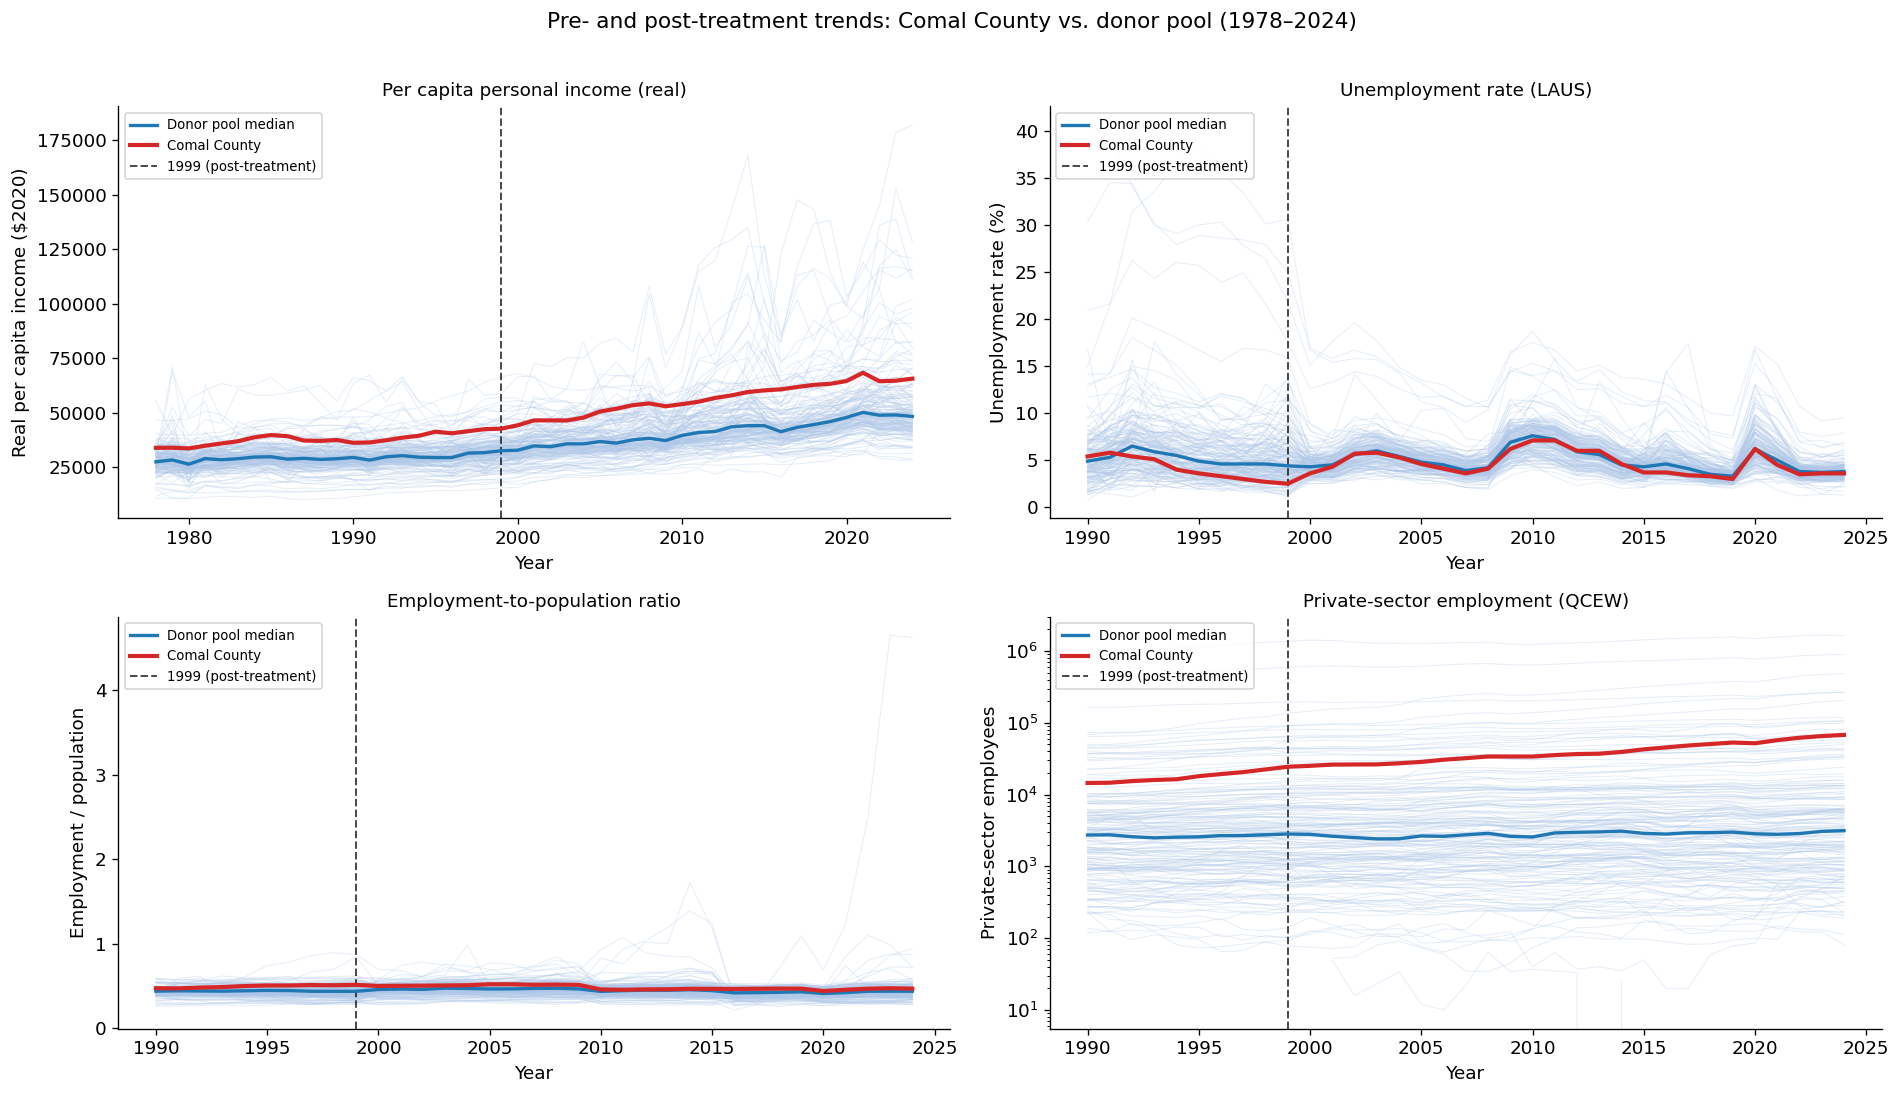

Saved: data/processed/panels/trends_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

plot_trends('per_capita_income_real',
            'Real per capita income ($2020)',
            'Per capita personal income (real)',
            ax=axes[0, 0])

plot_trends('laus_unemployment_rate',
            'Unemployment rate (%)',
            'Unemployment rate (LAUS)',
            ax=axes[0, 1])

plot_trends('emp_pop_ratio',
            'Employment / population',
            'Employment-to-population ratio',
            ax=axes[1, 0])

plot_trends('qcew_employment',
            'Private-sector employees',
            'Private-sector employment (QCEW)',
            log_scale=True,
            ax=axes[1, 1])

plt.suptitle('Pre- and post-treatment trends: Comal County vs. donor pool (1978–2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/panels/trends_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/panels/trends_overview.png')

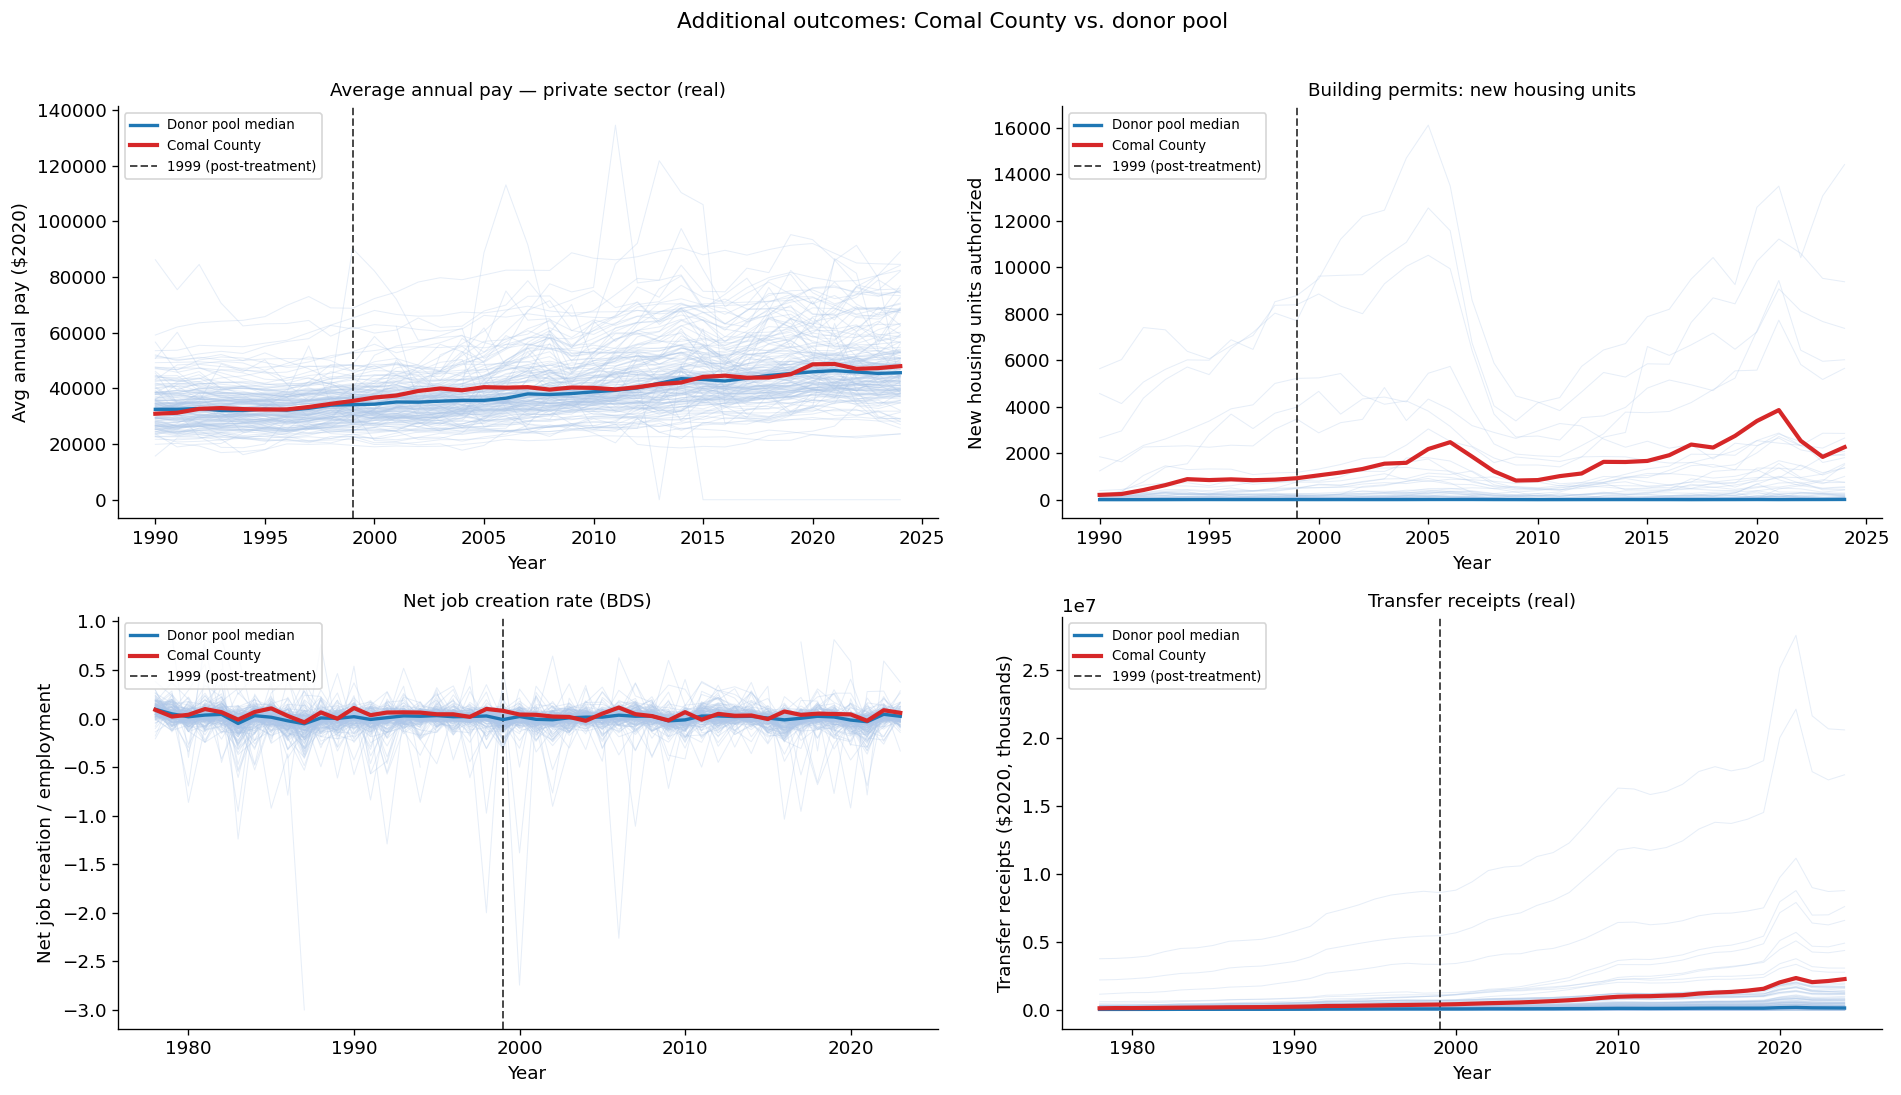

In [9]:
# Additional trends: wages, building permits, business dynamics
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

plot_trends('qcew_avg_annual_pay_real',
            'Avg annual pay ($2020)',
            'Average annual pay — private sector (real)',
            ax=axes[0, 0])

plot_trends('bps_units',
            'New housing units authorized',
            'Building permits: new housing units',
            ax=axes[0, 1])

plot_trends('net_job_creation_rate',
            'Net job creation / employment',
            'Net job creation rate (BDS)',
            ax=axes[1, 0])

plot_trends('transfer_receipts_real',
            'Transfer receipts ($2020, thousands)',
            'Transfer receipts (real)',
            ax=axes[1, 1])

plt.suptitle('Additional outcomes: Comal County vs. donor pool', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/panels/trends_additional.png', dpi=150, bbox_inches='tight')
plt.show()

## 5  Balance Table

Pre-treatment means for Comal County versus the donor pool.  
Window: **1990–1998** (where LAUS, QCEW, CBP, BPS all overlap).

In [10]:
PRE_START = 1990
PRE_END   = 1998

# Variables for balance table (real/rate/ratio values only)
balance_vars = [
    'per_capita_income_real',
    'personal_income_real',
    'net_earnings_real',
    'transfer_receipts_real',
    'laus_unemployment_rate',
    'emp_pop_ratio',
    'qcew_employment',
    'qcew_avg_annual_pay_real',
    'qcew_establishments',
    'cbp_employment',
    'cbp_annual_payroll_real',
    'bps_units',
    'net_job_creation_rate',
    'population',
    'poverty_rate',
    'college_share',
    'median_household_income_real',
]
balance_vars = [v for v in balance_vars if v in panel.columns]

# Pre-treatment subsets
pre_comal  = comal[(comal['year'] >= PRE_START) & (comal['year'] <= PRE_END)]
pre_donors = donors[(donors['year'] >= PRE_START) & (donors['year'] <= PRE_END)]

rows = []
for var in balance_vars:
    comal_mean = pre_comal[var].mean()
    donor_mean = pre_donors[var].mean()
    donor_std  = pre_donors[var].std()
    donor_med  = pre_donors[var].median()
    # Standardized difference: (Comal - donor mean) / donor SD
    std_diff = (comal_mean - donor_mean) / donor_std if donor_std > 0 else np.nan
    rows.append({
        'Variable': var,
        'Comal mean': comal_mean,
        'Donor mean': donor_mean,
        'Donor median': donor_med,
        'Donor SD': donor_std,
        'Std. diff.': std_diff,
    })

balance_df = pd.DataFrame(rows)

# Pretty format
fmt = {
    'Comal mean':   '{:,.1f}',
    'Donor mean':   '{:,.1f}',
    'Donor median': '{:,.1f}',
    'Donor SD':     '{:,.1f}',
    'Std. diff.':   '{:.3f}',
}
print(f'Balance table (pre-treatment {PRE_START}–{PRE_END})')
print(balance_df.to_string(index=False))

Balance table (pre-treatment 1990–1998)
                    Variable   Comal mean   Donor mean  Donor median     Donor SD  Std. diff.
      per_capita_income_real 3.919662e+04 3.072780e+04  29860.120650 7.161484e+03    1.182552
        personal_income_real 2.418335e+06 1.931631e+06 330331.752663 8.210519e+06    0.059278
           net_earnings_real 1.098223e+06 1.500663e+06 209402.897355 8.427237e+06   -0.047755
      transfer_receipts_real 3.136530e+05 2.300941e+05  66928.040841 7.290822e+05    0.114608
      laus_unemployment_rate 4.255556e+00 6.151007e+00      5.100000 4.463537e+00   -0.424652
               emp_pop_ratio 4.907839e-01 4.378126e-01      0.438499 6.308904e-02    0.839628
             qcew_employment 1.749000e+04 1.848801e+04   2612.000000 9.696805e+04   -0.010292
    qcew_avg_annual_pay_real 3.252838e+04 3.366517e+04  32668.909210 7.930135e+03   -0.143351
         qcew_establishments 1.407444e+03 1.188353e+03    276.000000 5.090854e+03    0.043036
              cbp_em

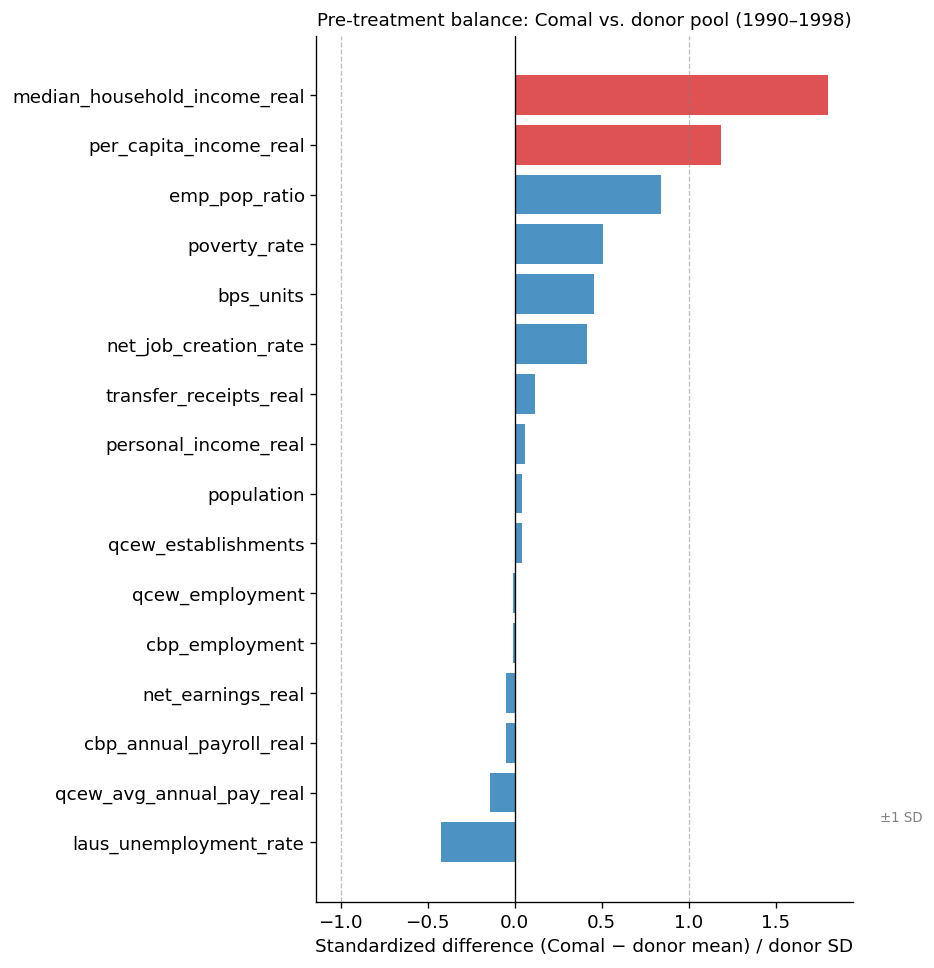

Red bars = |std diff| > 1 (Comal is notably different from donor average in that variable)


In [11]:
# Dot plot: standardized differences
bal = balance_df.dropna(subset=['Std. diff.']).sort_values('Std. diff.')

fig, ax = plt.subplots(figsize=(8, len(bal) * 0.45 + 1))
colors = ['#d62728' if abs(v) > 1.0 else '#1f77b4' for v in bal['Std. diff.']]
ax.barh(bal['Variable'], bal['Std. diff.'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 1, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(-1, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Standardized difference (Comal − donor mean) / donor SD')
ax.set_title(f'Pre-treatment balance: Comal vs. donor pool ({PRE_START}–{PRE_END})',
             fontsize=11)
ax.text(1.05, 0.5, '±1 SD', transform=ax.get_yaxis_transform(),
        fontsize=8, color='gray', va='center')
plt.tight_layout()
plt.savefig('../data/processed/panels/balance_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red bars = |std diff| > 1 (Comal is notably different from donor average in that variable)')

## 6  Pre-Treatment Window Assessment

How much of the panel is complete for Comal County in different time windows?  
This informs the choice of pre-treatment period for SCM optimization.

In [12]:
windows = [
    ('1978–1998 (full pre-period)', 1978, 1998),
    ('1986–1998 (CBP available)',   1986, 1998),
    ('1990–1998 (all major sources)', 1990, 1998),
    ('1995–1998 (QWI available)',   1995, 1998),
]

scm_vars = [
    'per_capita_income_real',
    'laus_unemployment_rate',
    'emp_pop_ratio',
    'qcew_employment',
    'qcew_avg_annual_pay_real',
    'cbp_employment',
    'bps_units',
    'net_job_creation_rate',
    'poverty_rate',
    'college_share',
]
scm_vars = [v for v in scm_vars if v in comal.columns]

print(f'Variable completeness for Comal County by window')
print(f'  (# years without any missing value in key SCM variables)')
print()
for label, y0, y1 in windows:
    sub = comal[(comal['year'] >= y0) & (comal['year'] <= y1)]
    n_total = len(sub)
    # For each variable, count non-missing years
    complete = {v: sub[v].notna().sum() for v in scm_vars}
    print(f'{label} ({n_total} years):')
    for v, c in sorted(complete.items(), key=lambda x: x[1]):
        pct = 100 * c / n_total
        bar = '█' * int(pct / 5)
        print(f'  {v:<35s} {c:2d}/{n_total} ({pct:5.1f}%) {bar}')
    print()

Variable completeness for Comal County by window
  (# years without any missing value in key SCM variables)

1978–1998 (full pre-period) (21 years):
  laus_unemployment_rate               9/21 ( 42.9%) ████████
  emp_pop_ratio                        9/21 ( 42.9%) ████████
  qcew_employment                      9/21 ( 42.9%) ████████
  qcew_avg_annual_pay_real             9/21 ( 42.9%) ████████
  bps_units                            9/21 ( 42.9%) ████████
  cbp_employment                      13/21 ( 61.9%) ████████████
  per_capita_income_real              21/21 (100.0%) ████████████████████
  net_job_creation_rate               21/21 (100.0%) ████████████████████
  poverty_rate                        21/21 (100.0%) ████████████████████
  college_share                       21/21 (100.0%) ████████████████████

1986–1998 (CBP available) (13 years):
  laus_unemployment_rate               9/13 ( 69.2%) █████████████
  emp_pop_ratio                        9/13 ( 69.2%) █████████████
  qcew

## 7  Outlier Detection in Donor Pool

Flag donor counties with extreme values (|z| > 3) in the pre-treatment period.  
Extreme outliers in specific variables may indicate data errors or structural incomparability.

In [13]:
# Z-scores within pre-treatment donor pool
pre_donors_pre = donors[(donors['year'] >= 1990) & (donors['year'] <= 1998)]

check_vars = [
    'per_capita_income_real',
    'laus_unemployment_rate',
    'qcew_avg_annual_pay_real',
    'net_job_creation_rate',
    'bps_units',
]
check_vars = [v for v in check_vars if v in donors.columns]

outlier_records = []
for var in check_vars:
    sub = pre_donors_pre[['fips', 'year', var]].dropna()
    mu = sub[var].mean()
    sd = sub[var].std()
    sub = sub.copy()
    sub['z'] = (sub[var] - mu) / sd
    extremes = sub[sub['z'].abs() > 3]
    for _, row in extremes.iterrows():
        outlier_records.append({
            'variable': var,
            'fips': row['fips'],
            'year': int(row['year']),
            'value': row[var],
            'z_score': round(row['z'], 2),
        })

outliers = pd.DataFrame(outlier_records).sort_values('z_score', key=abs, ascending=False)
print(f'County-year outliers (|z| > 3) in pre-treatment donor pool:')
print(f'Total: {len(outliers)}')
outliers.head(30)

County-year outliers (|z| > 3) in pre-treatment donor pool:
Total: 141


,variable,fips,year,value,z_score
86,net_job_creation_rate,48033,1998,-2.000000,-16.53
107,net_job_creation_rate,48487,1992,-1.291156,-10.70
137,bps_units,48439,1998,8521.000000,8.81
124,bps_units,48113,1998,8367.000000,8.65
115,bps_units,48085,1998,8031.000000,8.29
105,net_job_creation_rate,48413,1998,-0.974311,-8.09
43,laus_unemployment_rate,48427,1990,40.600000,7.72
118,bps_units,48113,1992,7410.000000,7.63
119,bps_units,48113,1993,7312.000000,7.53
44,laus_unemployment_rate,48427,1991,39.500000,7.47


In [14]:
# Which counties appear most often as outliers?
if len(outliers) > 0:
    top_outlier_fips = outliers.groupby('fips').size().sort_values(ascending=False)
    print('Counties with most outlier observations:')
    print(top_outlier_fips.head(15).to_string())
    print()
    print('Note: These counties may warrant exclusion from the donor pool or investigation.')
else:
    print('No extreme outliers found.')

Counties with most outlier observations:
fips
48085    13
48113    11
48427     9
48323     9
48425     9
48507     9
48065     9
48439     9
48377     8
48301     8
48421     6
48121     4
48413     3
48491     3
48205     3

Note: These counties may warrant exclusion from the donor pool or investigation.


## 8  Summary & Recommendations

This cell prints a structured summary to guide variable selection and donor pool screening.

In [15]:
print('=' * 60)
print('PANEL DIAGNOSTICS SUMMARY')
print('=' * 60)

print(f"""
Panel
  Dimensions : {panel.shape[0]:,} rows × {panel.shape[1]} columns
  Counties   : {panel['fips'].nunique()} TX counties (1978–{panel['year'].max()})
  Donor pool : {panel[panel['donor_eligible']==True]['fips'].nunique()} eligible counties

Recommended pre-treatment window for SCM optimization: 1990–1998
  Rationale: LAUS (unemployment), QCEW (employment/wages), CBP, and BPS
  all become available from 1990. This gives 9 pre-treatment years
  with near-complete data for the primary predictors.

  BEA per_capita_income_real is available from 1978 (47 years total);
  it can serve as the primary outcome with the full pre-period.

Primary outcome variable (recommended): per_capita_income_real
  → Available for Comal 1978–{comal['per_capita_income_real'].last_valid_index() or 'N/A'}
  → BEA data, 100% county coverage

Secondary outcomes (post-estimation check):
  → laus_unemployment_rate (1990+)
  → emp_pop_ratio (1990+)
  → qcew_employment (1990+)
  → bps_units (1990+, housing recovery signal)

Next step: Run notebooks/02_donor_screening.ipynb
  → Filter 171 eligible counties to ~30–60 by coverage, size, industry mix
  → Finalize predictor set for SCM
""")

# Comal 1998 population
pop_1998 = comal.loc[comal['year'] == 1998, 'population'].values
if len(pop_1998) > 0:
    print(f"Comal County 1998 population: {int(pop_1998[0]):,}")
    print(f"  → Donor pool size filter: {int(pop_1998[0]*0.2):,} – {int(pop_1998[0]*5):,} (0.2× to 5×)")

PANEL DIAGNOSTICS SUMMARY

Panel
  Dimensions : 11,938 rows × 63 columns
  Counties   : 254 TX counties (1978–2024)
  Donor pool : 171 eligible counties

Recommended pre-treatment window for SCM optimization: 1990–1998
  Rationale: LAUS (unemployment), QCEW (employment/wages), CBP, and BPS
  all become available from 1990. This gives 9 pre-treatment years
  with near-complete data for the primary predictors.

  BEA per_capita_income_real is available from 1978 (47 years total);
  it can serve as the primary outcome with the full pre-period.

Primary outcome variable (recommended): per_capita_income_real
  → Available for Comal 1978–2161
  → BEA data, 100% county coverage

Secondary outcomes (post-estimation check):
  → laus_unemployment_rate (1990+)
  → emp_pop_ratio (1990+)
  → qcew_employment (1990+)
  → bps_units (1990+, housing recovery signal)

Next step: Run notebooks/02_donor_screening.ipynb
  → Filter 171 eligible counties to ~30–60 by coverage, size, industry mix
  → Finalize 